In [1]:
%pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install load_dotenv

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


# Set up database

In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# SEXIAL LOG

In [24]:
query = "SELECT STR_TO_DATE(CONCAT(`DAY`, ' ', `SEXLOG_TIME`), '%Y-%m-%d %H:%i:%s') AS datetime_combined, SEXLOG_DURING, SATISFACTION, SEXLOG_SHOOT FROM `SEXUAL_LOG` NATURAL JOIN `DAY`"
sl = pd.read_sql(query, engine)
sl.head()

,datetime_combined,SEXLOG_DURING,SATISFACTION,SEXLOG_SHOOT
0,2025-06-20 14:30:00,short,very unsatisfied,None
1,2025-06-20 17:00:00,short,very unsatisfied,None
2,2025-06-20 23:30:00,medium,very unsatisfied,None
3,2025-06-21 18:30:00,medium,,None
4,2025-06-22 07:15:00,medium,,None


## Histogram

SEXLOG_SHOOT

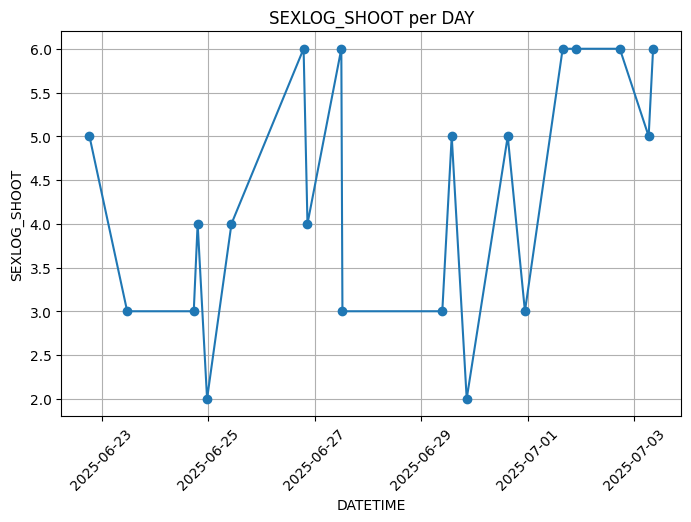

In [25]:
sl['SEXLOG_SHOOT'] = sl['SEXLOG_SHOOT'].str.strip().str.lower()

shoot_map = {
    "none": 1,
    "very weak": 2,
    "weak": 3,
    "moderate": 4,
    "strong": 5,
    "explosive": 6 
}

sl['shoot_score'] = sl['SEXLOG_SHOOT'].map(shoot_map)

plt.figure(figsize=(8, 5))
plt.plot(sl['datetime_combined'], sl['shoot_score'], marker='o')
plt.xlabel('DATETIME')
plt.ylabel('SEXLOG_SHOOT')
plt.title('SEXLOG_SHOOT per DAY')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## Distribution

Shoot intensity

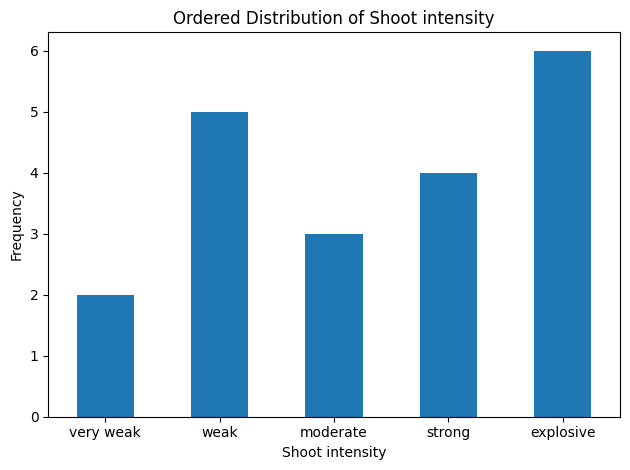

In [26]:
order = ["very weak", "weak", "moderate", "strong", "explosive"]
sl['SEXLOG_SHOOT'] = pd.Categorical(sl['SEXLOG_SHOOT'], categories=order, ordered=True)

sl['SEXLOG_SHOOT'].dropna().value_counts().sort_index().plot(kind='bar')

plt.xlabel("Shoot intensity")
plt.ylabel("Frequency")
plt.title("Ordered Distribution of Shoot intensity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sex during

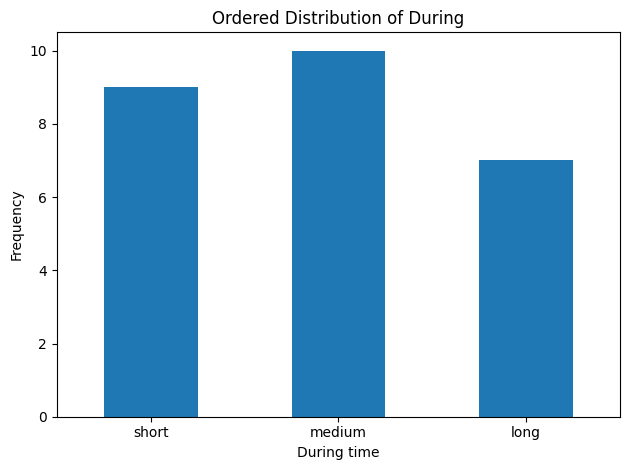

In [27]:
order = ["short","medium","long"]
sl['SEXLOG_DURING'] = pd.Categorical(sl['SEXLOG_DURING'], categories=order, ordered=True)

sl['SEXLOG_DURING'].dropna().value_counts().sort_index().plot(kind='bar')

plt.xlabel("During time")
plt.ylabel("Frequency")
plt.title("Ordered Distribution of During")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Satisfaction level

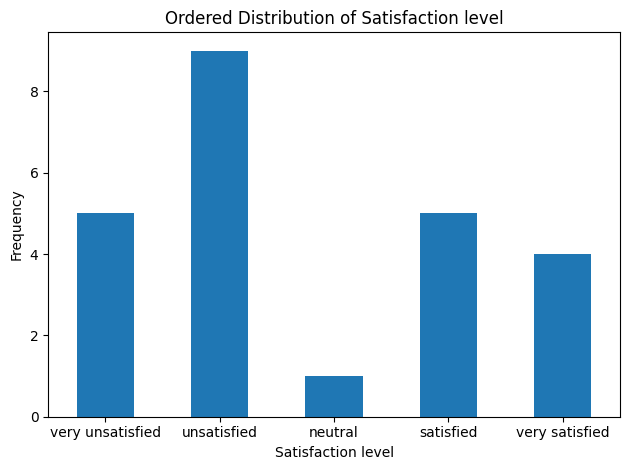

In [28]:
order = ["very unsatisfied", "unsatisfied", "neutral", "satisfied", "very satisfied"]
sl['SATISFACTION'] = pd.Categorical(sl['SATISFACTION'], categories=order, ordered=True)

sl['SATISFACTION'].dropna().value_counts().sort_index().plot(kind='bar')

plt.xlabel("Satisfaction level")
plt.ylabel("Frequency")
plt.title("Ordered Distribution of Satisfaction level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Box plot

In [29]:
sl['SATISFACTION'] = sl['SATISFACTION'].str.strip().str.lower()
sl['SEXLOG_DURING'] = sl['SEXLOG_DURING'].str.strip().str.lower()

satisfaction_map = {
    "very unsatisfied": 1,
    "unsatisfied": 2,
    "neutral": 3,
    "satisfied": 4,
    "very satisfied": 5
}

SEXLOG_DURING_map = {
    "short": 1,
    "medium": 2,
    "long": 3,
}

sl['SATISFACTION_SCORE'] = sl['SATISFACTION'].map(satisfaction_map)
sl['SEXLOG_DURING_SCORE'] = sl['SEXLOG_DURING'].map(SEXLOG_DURING_map)

In [30]:
print(sl['SATISFACTION_SCORE'].describe())

count    24.000000
mean      2.750000
std       1.452135
min       1.000000
25%       2.000000
50%       2.000000
75%       4.000000
max       5.000000
Name: SATISFACTION_SCORE, dtype: float64


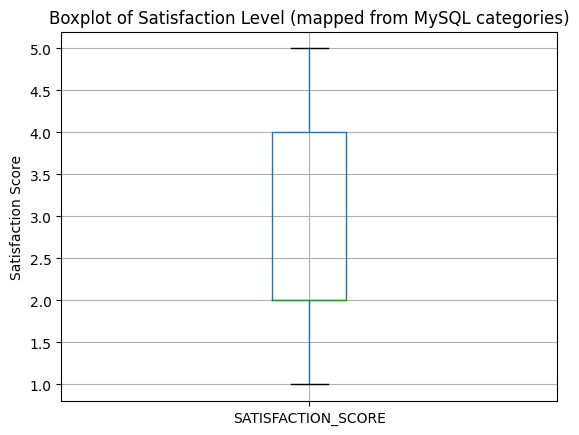

In [31]:
sl.boxplot(column='SATISFACTION_SCORE')
plt.ylabel("Satisfaction Score")
plt.title("Boxplot of Satisfaction Level (mapped from MySQL categories)")
plt.show()

## Correlative coefficient

SATISFACTION and SEXLOG DURING

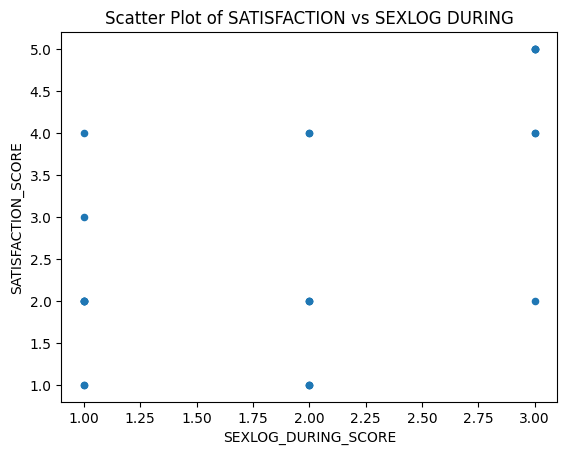

In [32]:
sl.plot(kind='scatter', x='SEXLOG_DURING_SCORE', y='SATISFACTION_SCORE')
plt.title('Scatter Plot of SATISFACTION vs SEXLOG DURING')
plt.show()

In [33]:
correlation = sl['SATISFACTION_SCORE'].corr(sl['SEXLOG_DURING_SCORE'])
print("Correlation coefficient:", correlation)

Correlation coefficient: 0.5954247698393582
